## Text Classification with Keras

In [15]:
## Import Libraries 
import pandas as pd
import re
from sqlalchemy import create_engine
import nltk
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
from keras.layers import Dense,Activation,Dropout,Embedding,SpatialDropout1D

In [22]:
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.models import Model
from keras.layers import Dense, Flatten, LSTM, Conv1D, MaxPooling1D, Dropout, Activation, Input
from keras.layers.embeddings import Embedding

Using TensorFlow backend.


In [25]:
## Load Database

data = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-05-05/user_reviews.tsv", sep='\t')
data.head()

,grade,user_name,text,date
0,4,mds27272,My gf started playing before me. No option to ...,2020-03-20
1,5,lolo2178,"While the game itself is great, really relaxin...",2020-03-20
2,0,Roachant,My wife and I were looking forward to playing ...,2020-03-20
3,0,Houndf,We need equal values and opportunities for all...,2020-03-20
4,0,ProfessorFox,BEWARE! If you have multiple people in your h...,2020-03-20


## EDA

Text(0.5, 1.0, 'Grade Distribution')

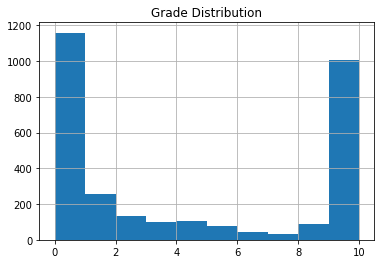

In [30]:
data['grade'].hist()
plt.title('Grade Distribution')

In [78]:
text = pd.Series.to_string(text)
def clean_text(text):
    text = text.lower()
    text = re.sub('#',' ', text)
    text = re.sub(r"what's", 'what is ', text)
    text = re.sub(r"can't", 'cannot', text)
    text = re.sub(r"\'s",' ', text)
    text = re.sub(r"\'ve", ' have ', text)
    text = re.sub(r"n't", ' not ', text)
    text = re.sub(r"im", 'i am ', text)
    text = re.sub(r"i'm", 'i am ', text)
    text = re.sub(r"\'re", ' are ', text)
    text = re.sub(r"\'d", ' would ', text)
    text = re.sub(r"\'ll", ' will ', text)
    text = re.sub(r",", " ", text)
    text = re.sub(r"\.", " ", text)
    text = re.sub(r"!", " ! ", text)
    text = re.sub(r"\/", " ", text)
    text = re.sub(r"\^", " ^ ", text)
    text = re.sub(r"\+", " + ", text)
    text = re.sub(r"\-", " - ", text)
    text = re.sub(r"\=", " = ", text)
    text = re.sub('foof', 'food', text)
    text = re.sub('msg', 'message', text)
    text = re.sub(' u ', 'you', text)
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text)
    text = re.sub("^\d+\s|\s\d+\s|\s\d+$", " ", text)
    text = text.split()
    stop_words = stopwords.words("english")
    text = [tok for tok in text if tok not in stop_words]
    lemmatizer = WordNetLemmatizer()
    text = [lemmatizer.lemmatize(w) for w in text]
    return(text)


In [79]:
clean_text(text)

['gf',
 'started',
 'playing',
 'option',
 'game',
 'great',
 'really',
 'relaxin',
 'wife',
 'looking',
 'forward',
 'playing',
 'need',
 'equal',
 'value',
 'opportunity',
 'beware',
 'multiple',
 'people',
 'h',
 'li',
 'itation',
 'one',
 'island',
 'per',
 'switch',
 'p',
 'excited',
 'new',
 'installment',
 'reason',
 'nintendo',
 'dec',
 'annoying',
 'one',
 'player',
 'purchased',
 'game',
 'household',
 'heavily',
 'marketed',
 'game',
 'social',
 'ex',
 'one',
 'island',
 'per',
 'switch',
 'mu',
 'one',
 'island',
 'per',
 'console',
 'cannot',
 'create',
 'create',
 'one',
 'island',
 'per',
 'switch',
 'one',
 'island',
 'per',
 'console',
 'pretty',
 'terrible',
 'add',
 'local',
 'co',
 'op',
 'one',
 'isl',
 'forcing',
 'island',
 'per',
 'account',
 'one',
 'person',
 'play',
 'switch',
 'eve',
 'absolutely',
 'ridiculous',
 'member',
 'one',
 'island',
 'per',
 'console',
 'ruined',
 'game',
 'alright',
 'first',
 'thing',
 'first',
 'game',
 'fan',
 'saga',
 'game',


## LSTM

In [93]:
MAX_NB_WORDS = 50000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 100
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)
tokenizer.fit_on_texts(data['text'].values)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

Found 10335 unique tokens.


In [94]:
X = tokenizer.texts_to_sequences(data['text'].values)
X = pad_sequences(X, maxlen=MAX_SEQUENCE_LENGTH)
print('Shape of data tensor:', X.shape)

Shape of data tensor: (2999, 200)


In [97]:
Y = pd.get_dummies(data['grade']).values
print('Shape of label tensor:', Y.shape)

Shape of label tensor: (2999, 11)


In [125]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.30, random_state = 1234)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(2099, 200) (2099, 11)
(900, 200) (900, 11)


In [128]:
model = Sequential()
model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(11, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

epochs = 5
batch_size = 64

history = model.fit(X_train, Y_train, epochs=epochs, batch_size=batch_size,validation_split=0.1,callbacks=[EarlyStopping(monitor='val_loss', patience=3, min_delta=0.0001)])


Train on 1889 samples, validate on 210 samples
Epoch 1/5
1889/1889 [==============================] - 7s 3ms/step - loss: 2.0368 - accuracy: 0.3753 - val_loss: 1.7862 - val_accuracy: 0.4238
Epoch 2/5
1889/1889 [==============================] - 6s 3ms/step - loss: 1.8070 - accuracy: 0.4013 - val_loss: 1.7709 - val_accuracy: 0.4238
Epoch 3/5
1889/1889 [==============================] - 6s 3ms/step - loss: 1.7066 - accuracy: 0.4643 - val_loss: 1.5839 - val_accuracy: 0.5524
Epoch 4/5
1889/1889 [==============================] - 6s 3ms/step - loss: 1.4589 - accuracy: 0.5712 - val_loss: 1.4069 - val_accuracy: 0.5952
Epoch 5/5
1889/1889 [==============================] - 6s 3ms/step - loss: 1.2869 - accuracy: 0.6030 - val_loss: 1.3636 - val_accuracy: 0.6143


In [129]:
accr = model.evaluate(X_test,Y_test)
print('Test set\n  Loss: {:0.3f}\n  Accuracy: {:0.3f}'.format(accr[0],accr[1]))

900/900 [==============================] - 1s 726us/step
Test set
  Loss: 1.463
  Accuracy: 0.572


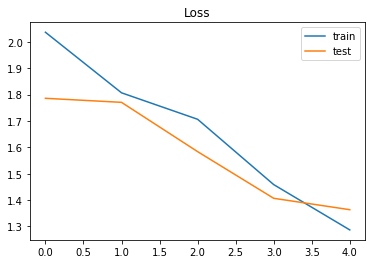

In [130]:
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

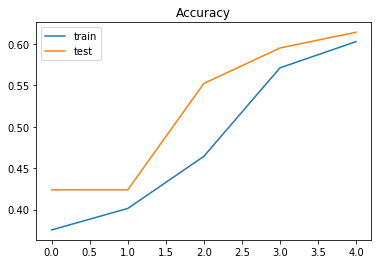

In [135]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show();

In [137]:
data.head()

,grade,user_name,text,date
0,4,mds27272,"[gf, started, playing, option, create, island,...",2020-03-20
1,5,lolo2178,"[game, great, really, relaxing, gorgeous, cann...",2020-03-20
2,0,Roachant,"[wife, looking, forward, playing, game, releas...",2020-03-20
3,0,Houndf,"[need, equal, value, opportunity, player, isla...",2020-03-20
4,0,ProfessorFox,"[beware, multiple, people, house, want, play, ...",2020-03-20


In [138]:
data.text

0       [gf, started, playing, option, create, island,...
1       [game, great, really, relaxing, gorgeous, cann...
2       [wife, looking, forward, playing, game, releas...
3       [need, equal, value, opportunity, player, isla...
4       [beware, multiple, people, house, want, play, ...
                              ...                        
2994    [island, console, li, itation, cannot, play, g...
2995    [per, giocare, con, figli, fidanzate, mogli, p...
2996    [one, island, per, console, pathetic, li, itat...
2997    [even, though, seems, like, great, game, many,...
2998    [game, fantastic, nintendo, deciding, make, on...
Name: text, Length: 2999, dtype: object

In [179]:
new_complaint = ['My wife and I were looking forward to playing and she is happy for my play']
seq = tokenizer.texts_to_sequences(new_complaint)
padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH)
pred = model.predict(padded)
pred
labels = label

In [180]:
print(pred, labels[np.argmax(pred)])

[[0.09881765 0.02435686 0.01796898 0.00943272 0.01520556 0.01650386
  0.01212973 0.00987632 0.04316001 0.13625342 0.6162949 ]] ['heavily', 'marketed', 'game', 'social', 'experience', 'game', 'share', 'friend', 'family', 'here', 'catch', 'need', 'nintendo', 'switch', 'player', 'get', 'full', 'experience', 'bought', 'game', 'share', 'girlfriend', 'first', 'player', 'considered', 'founder', 'island', 'one', 'progress', 'story', 'unlock', 'stuff', 'dothey', 'heavily', 'marketed', 'game', 'social', 'experience', 'game', 'share', 'friend', 'family', 'here', 'catch', 'need', 'nintendo', 'switch', 'player', 'get', 'full', 'experience', 'bought', 'game', 'share', 'girlfriend', 'first', 'player', 'considered', 'founder', 'island', 'one', 'progress', 'story', 'unlock', 'stuff', 'cool', 'thing', 'second', 'nintendo', 'switch', 'profile', 'act', 'merely', 'villager', 'little', 'pact', 'game', 'able', 'progress', 'without', 'founder', 'progress', 'game', 'ruined', 'greed', 'want', 'full', 'experienc